In [43]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
import google.generativeai as genai
from dotenv import load_dotenv

In [44]:
model = genai.GenerativeModel("gemini-1.5-flash")

In [45]:
class LLMState(TypedDict):
    question:str
    answer:str

In [46]:
def llm_q(state:LLMState)->LLMState:
    question=state['question']

    prompt=f"answer the following question {question}"

    answer=model.invoke(prompt).content


    return {"answer": answer.text}

In [47]:
graph=StateGraph(LLMState)

graph.add_node('llm_q',llm_q)

graph.add_edge(START,'llm_q')
graph.add_edge('llm_q',END)

workflow=graph.compile()


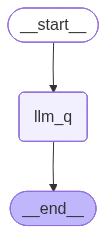

In [48]:
workflow

In [49]:
intial_state={"question":"what is the captail of india"}

In [50]:
result=workflow.invoke(intial_state)


AttributeError: 'GenerativeModel' object has no attribute 'invoke'

Running workflow...
Thinking about: What is the capital of India?...
------------------------------
Final Answer: Error aa gaya bhai: 404 models/gemini-1.0-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
------------------------------
